In [2]:
################################## attention layer ##################################
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math

import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

In [2]:
# Library of Helper Functions

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
#     fname='/home/yibei/Projects/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)      
        
def tokenize(str):
    out = []
    for i in range(len(str)-4):
        out.append(str[i:i+5])
    return out

# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [3]:
# Helper function to plot data colored with attention weights
class CharVal(object):
    def __init__(self, char, val):
        self.char = char
        self.val = val

    def __str__(self):
        return self.char

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb

def color_charvals(s):
    r = 255-int(s.val*255)
#     r = int(s.val*255)
#     print(r)
    color = rgb_to_hex((r, r, 255))
    return 'background-color: %s' % color

# a list of 5mers, token and a list of their attention values, currseq_attention_output
def plot_attention_from_seq(token, currseq_attention_output):

    vals_normalized = min_max_norm(currseq_attention_output)
#     print(vals_normalized)
    # match each 5mer with sum of the 320 dim array attention weight array
    char_vals = [CharVal(c, v) for c, v in zip(token, vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df


def plot_attention_from_map(map):

    # match each 5mer with sum of the 320 dim array attention weight array
    vals_normalized = min_max_norm(map.values())
    char_vals = [CharVal(c, v) for c, v in zip(map.keys(), vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df

In [3]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/"

data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2_reduced_dense10/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model3/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel9_run3/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run3/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/ShapeDNN/train_debug/"
model = load_model(data_folder+"tbinet.h5")

model.summary()



OSError: SavedModel file does not exist at: /Users/yibeijia/Downloads/nucleosome_occupancy/ShapeDNN/train_debug/tbinet.h5/{saved_model.pbtxt|saved_model.pb}

# 1. Generate Attention weights for all data

In [10]:
def generateAttentionWeights(model):
    ## load model with its attention weights using the layer
#     attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('multiply').output])
    attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('attention2').output])
    ## Set up a set of data for predict call, this case, taking every 10 data point
#     data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"
    data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

    # load testmat from file
    testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
    batches = 10
    batch_size = round(len(testmat['Test_data'])/batches)
    print(f"batch_size: {batch_size}; batches: {batches}")
    model_outputs=[]
    attention_outputs=[]
    model_outputs0=[]
    attention_outputs0=[]
    model_outputs1=[]
    attention_outputs1=[]

    for i in range(batches):
#     for i in range(2):
        start = i*batch_size
        end = (i+1)*batch_size
        print(f"start: {start}; end: {end}")
        d = testmat['Test_data'][start:end]
        labels = testmat['Test_labels']
        new_labels = labels[0][start:end]

        # get the index of data that is 0 or 1 
        ones = np.flatnonzero(new_labels == np.max(new_labels))
        zeros = np.flatnonzero(new_labels == np.min(new_labels))
    #     print(f'ones.shape {ones.shape}')
    #     print(f'zeros.shape {zeros.shape}')

        # # get all model output and attention weights
        attention_wt = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
        model_out = attention_wt[0]
        attention_out = attention_wt[1]
    #     print(f'model.shape {len(model_out)}')

        # separate 0 and 1
        attention_out0 = [attention_out[i] for i in zeros]
        attention_out1 = [attention_out[i] for i in ones]
#         model_out0 = [model_out[i] for i in zeros]
#         model_out1 = [model_out[i] for i in ones]

        # Concatenate current batch with the rest of batches
        if len(attention_outputs) == 0: # if initialize
#             model_outputs = model_out
#             model_outputs0 = model_out0
#             model_outputs1 = model_out1

            attention_outputs = attention_out
            attention_outputs0 = attention_out0
            attention_outputs1 = attention_out1
#             print(attention_outputs)

        else:
#             model_outputs = np.concatenate((model_outputs, model_out), axis=0)
#             model_outputs1 = np.concatenate((model_outputs1, model_out1), axis=0)
#             model_outputs0 = np.concatenate((model_outputs0, model_out0), axis=0)
            attention_outputs = np.concatenate((attention_outputs, attention_out), axis=0)
            attention_outputs0 = np.concatenate((attention_outputs0, attention_out0), axis=0)
            attention_outputs1 = np.concatenate((attention_outputs1, attention_out1), axis=0)

#     r = len(attention_outputs)
#     c = len(attention_outputs[0])
#     l = len(attention_outputs[0][0])
#     print(f"The all attention_outputs Array is {r} x {c} x {l}")

#     r = len(attention_outputs0)
#     c = len(attention_outputs0[0])
#     l = len(attention_outputs0[0][0])
#     print(f"The 0 attention_outputs Array is {r} x {c} x {l}")

#     r = len(attention_outputs1)
#     c = len(attention_outputs1[0])
#     l = len(attention_outputs1[0][0])
#     print(f"The 1 attention_outputs Array is {r} x {c} x {l}")
    return attention_outputs, attention_outputs0, attention_outputs1

In [ ]:
np.save(f"/Users/yibeijia/Downloads/data/attention_outputs_analyze_attention3.npy", attention_outputs)
np.save(f"/Users/yibeijia/Downloads/data/attention_outputs_analyze0_attention3.npy", attention_outputs0)
np.save(f"/Users/yibeijia/Downloads/data/attention_outputs_analyze1_attention3.npy", attention_outputs1)

In [6]:

attention_outputs = np.load("/Users/yibeijia/Downloads/data/attention_outputs_analyze_attention3.npy")
attention_outputs0 = np.load("/Users/yibeijia/Downloads/data/attention_outputs_analyze0_attention3.npy")
attention_outputs1 = np.load("/Users/yibeijia/Downloads/data/attention_outputs_analyze1_attention3.npy")

In [7]:
print(len(attention_outputs))
print(len(attention_outputs0))
print(len(attention_outputs1))

150890
91621
59269


# 1. Plot attention score from run10 model for all 5mers

In [9]:
# # if you are using batches the outputs will be in batches
# # get exact attentions of chars
# i=0 #get attention map for ith sequence
# currseq_attention_output = sum(attention_outputs[i])
# token = tokenize(ReverseOneHotEncode(d[i]))
# char_df = plot_attention_from_seq(token, currseq_attention_output)
# (char_df)

In [10]:
# mapped = dict(zip(token, currseq_attention_output))
# print(mapped)

## 1.1 Don't add reverse Complements scores and treat them separately

In [11]:
# Put all the 5mers and their added total attention scores across sequences in dictionary
def sumAttentionforAllKmers(attention_outputs, d):
    from IPython.display import display
    mapped = {}
    kmerCounts = {}
    seqCount=0

    print(f"Total Attention Seq Num: {len(attention_outputs)}")
    print(f"Total Data Seq: {len(d)}")
    
    for seq in range(len(attention_outputs)):
        seqCount+=1
    # for seq in range(1,500):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        #     for i in range(len(attention_outputs[0])):
        for i in range(len(tokens)):
    #         print(token)
            token = tokens[i]
            if token in kmerCounts.keys():
                kmerCounts[token] = kmerCounts[token] + 1
            else:
                kmerCounts[token] = 1
#             five_mer_attention_output = sum(attention_outputs[seq][i])
            five_mer_attention_output = attention_outputs[seq][i]
            if token in mapped.keys():  # if a 5mer is found
                mapped[token] = mapped[token] + five_mer_attention_output #increase value
            else: #if 5mer not seen yet
                mapped[token] = five_mer_attention_output
        
    #     char_df = plot_attention_from_seq(tokens, mapped[token])
    #     display(char_df)

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections
    ordered_map = collections.OrderedDict(sorted(mapped.items()))
    return ordered_map, kmerCounts, seqCount


In [12]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
d=testmat['Test_data'] # need to redefine d
labels = testmat['Test_labels']
new_labels = labels[0]

# get the index of data that is 0 or 1 
ones = np.flatnonzero(new_labels == np.max(new_labels))
zeros = np.flatnonzero(new_labels == np.min(new_labels))
d0 = [d[i] for i in zeros]
d1 = [d[i] for i in ones]

print("Depleted Seqs")
ordered_map0, kmerCounts0, seqCount0 = sumAttentionforAllKmers(attention_outputs0, d0)
print("Enriched Seqs")
ordered_map1, kmerCounts1, seqCount1 = sumAttentionforAllKmers(attention_outputs1, d1)
print("ALL Seqs")
ordered_map, kmerCounts, seqCount = sumAttentionforAllKmers(attention_outputs, d)
print(f"seqCount0: {seqCount0}")
print(f"seqCount1: {seqCount1}")
print(f"seqCount: {seqCount}")

Depleted Seqs
Total Attention Seq Num: 91621
Total Data Seq: 91621
Enriched Seqs
Total Attention Seq Num: 59269
Total Data Seq: 59269
ALL Seqs
Total Attention Seq Num: 150890
Total Data Seq: 150890
seqCount0: 91621
seqCount1: 59269
seqCount: 150890


In [35]:
############################## Normalize by Kmer cout ##############################
# # print(ordered_kmerCounts.keys())
# # ordered_map = collections.OrderedDict(sorted(mapped.items()))
# def normKmerCount(ordered_map, kmerCounts):
#     ordered_map_norm = {}
#     for k, _ in ordered_map.items():
#         v = ordered_map[k] / kmerCounts[k]
#         ordered_map_norm[k] = v
#     return ordered_map_norm

# ordered_map_norm = normKmerCount(ordered_map, kmerCounts)
# ordered_map_norm0 = normKmerCount(ordered_map0, kmerCounts0)
# ordered_map_norm1 = normKmerCount(ordered_map1, kmerCounts1)

# print(len(ordered_map_norm))
# # print(len(ordered_map))
# print(len(ordered_map_norm0))
# print(len(ordered_map_norm1))

1024
1024
1024


In [13]:
############################## Normalize by Seq cout ##############################
def normSeqCount(ordered_map, seqCount):
    ordered_map_norm = {}
    for k, _ in ordered_map.items():
        v = ordered_map[k] / seqCount
        ordered_map_norm[k] = v
    return ordered_map_norm
ordered_map_norm = normSeqCount(ordered_map, seqCount)
ordered_map_norm0 = normSeqCount(ordered_map0, seqCount0)
ordered_map_norm1 = normSeqCount(ordered_map1, seqCount1)

print(len(ordered_map_norm))
# print(len(ordered_map))
print(len(ordered_map_norm0))
print(len(ordered_map_norm1))

1024
1024
1024


In [17]:
max(ordered_map0.values())

3355.6575

In [4]:
ordered_map_norm0

NameError: name 'ordered_map_norm0' is not defined

In [19]:
ordered_map0

OrderedDict([('AAAAA', 3254.5823),
             ('AAAAC', 289.50616),
             ('AAAAG', 533.8836),
             ('AAAAT', 1302.0546),
             ('AAACA', 193.8891),
             ('AAACC', 112.46834),
             ('AAACG', 78.22434),
             ('AAACT', 201.26794),
             ('AAAGA', 429.42267),
             ('AAAGC', 100.0651),
             ('AAAGG', 153.05893),
             ('AAAGT', 330.6526),
             ('AAATA', 668.9304),
             ('AAATC', 274.20618),
             ('AAATG', 250.983),
             ('AAATT', 907.8383),
             ('AACAA', 225.75616),
             ('AACAC', 59.637714),
             ('AACAG', 49.215607),
             ('AACAT', 145.94916),
             ('AACCA', 87.16885),
             ('AACCC', 68.22269),
             ('AACCG', 24.654373),
             ('AACCT', 117.84446),
             ('AACGA', 42.482788),
             ('AACGC', 21.581245),
             ('AACGG', 16.341501),
             ('AACGT', 59.754013),
             ('AACTA', 134.5443

In [19]:
ordered_map_norm1

{'AAAAA': 0.0067256393346371525,
 'AAAAC': 0.0015343865905935756,
 'AAAAG': 0.0020666949654742175,
 'AAAAT': 0.0027089096672025794,
 'AAACA': 0.0016464292354429592,
 'AAACC': 0.0012127203806908174,
 'AAACG': 0.0008502496087546491,
 'AAACT': 0.0013050839530443956,
 'AAAGA': 0.002169797024230231,
 'AAAGC': 0.0011783099049395025,
 'AAAGG': 0.0013184103243049565,
 'AAAGT': 0.0017483121409214502,
 'AAATA': 0.0018424310056509437,
 'AAATC': 0.0016784903535268622,
 'AAATG': 0.0016320758971411066,
 'AAATT': 0.0021321794969789486,
 'AACAA': 0.00247532242223683,
 'AACAC': 0.001306556565597965,
 'AACAG': 0.0009830772658510614,
 'AACAT': 0.001787752798557016,
 'AACCA': 0.0013557550835491573,
 'AACCC': 0.0014367284354654467,
 'AACCG': 0.0004054762074953351,
 'AACCT': 0.0017897199720748173,
 'AACGA': 0.0006128055091271826,
 'AACGC': 0.000611005420495267,
 'AACGG': 0.0003549532393200453,
 'AACGT': 0.0011442935847510397,
 'AACTA': 0.0008697862471778565,
 'AACTC': 0.0012779795149419385,
 'AACTG': 0.0006

In [20]:
max(ordered_map_norm0.values())

0.021614401650895163

In [21]:
max(ordered_map_norm1.values())

0.0201407117382896

In [22]:
max(ordered_map_norm.values())

0.02421056613571973

In [14]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

# fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
fileName = "/Users/yibeijia/Downloads/ProjectStuff/pentamer_table.txt"
# fileName = "/home/yibei/Projects/nucleosome_occupancy/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);

# all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)
# print(len(all_norm_shape_vals))
len(tb.keys())

1024

In [15]:
################################### Correlation plots for reverse complements ###################################
def reverseCompPlot(map_to_plot, plot_name, annotation_x, annotation_y, removeA):
    import seaborn as sns
    import matplotlib.pyplot

    i=0
    five_mers = {}
    for k in map_to_plot.items():
        if k[0] in tb.keys(): #k[0] is not a reverse complement

            r = reverse_complement(k[0])
            values = [map_to_plot[k[0]], map_to_plot[r]] #first is 5mer, second is reverse complement value
            five_mers[k[0]] = values

    # Plot corr between 5mers and its reverse complements
    corr = pd.DataFrame.from_dict(five_mers,orient='index', columns=['five_mer', 'reverse_comp'])
    if removeA:
        corr = corr[1:]
        plot_name+='_removeA'
    
    sns.set_theme(style="darkgrid")

    g = sns.lmplot(x="five_mer", y="reverse_comp",data=corr);

    plt.gcf().set_size_inches(10, 8)
    # plt.title("Attension Score Correlation: \n5-mers vs. Reverse Complements\nafter Normalization", fontsize=15)
    plt.xlabel("5-mers Attention Scores", fontsize=25);
    
    plt.ticklabel_format(style='sci',scilimits=(0,0))
    plt.xticks(fontsize=20);
    plt.yticks(fontsize=20);
    plt.ylabel("Reverse complements Attention Scores", fontsize=25);

    # Add person correlation annotation
    from scipy import stats
    num = stats.pearsonr(corr['five_mer'], corr['reverse_comp'])[0]
    text = "Pearson Correlation \n= " + f'{num:.5f}'

    plt.text(annotation_x, annotation_y, text, horizontalalignment='center', fontsize=20, color='black', weight='semibold')
    
    plt.tight_layout()
#     plt.savefig( plot_name+'.png', dpi=200)

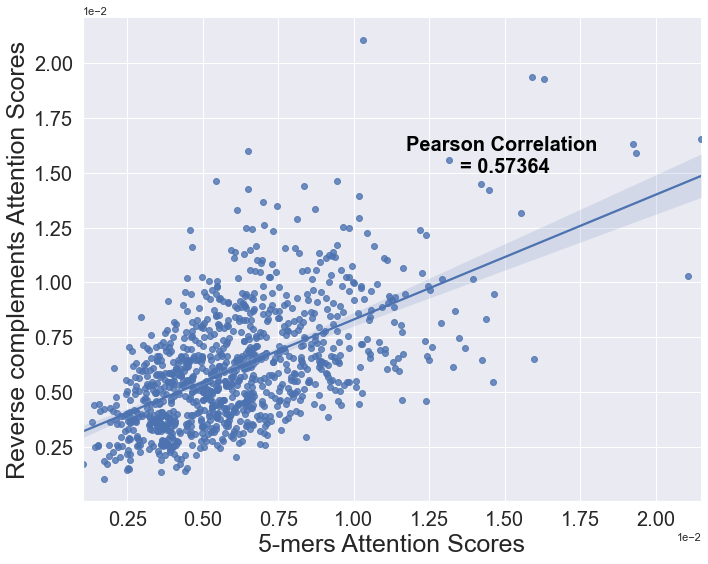

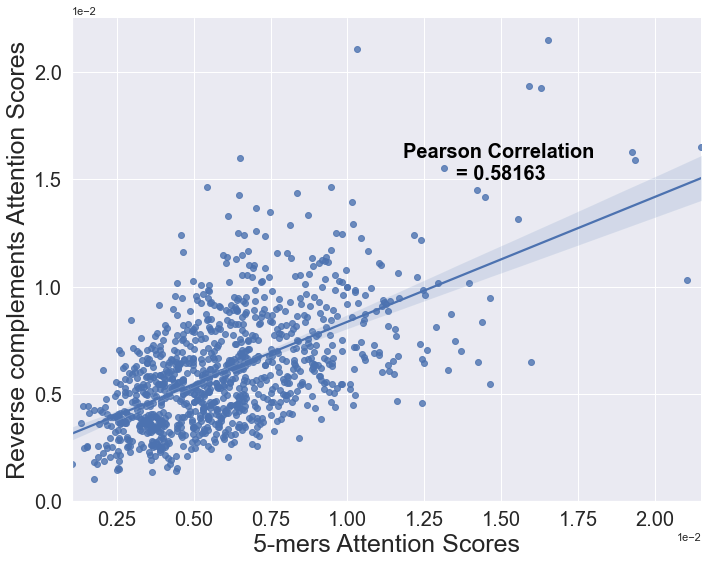

In [25]:
# fig_path='/home/yibei/Projects/nucleosome_occupancy/figs/'
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'

# reverseCompPlot(ordered_map, fig_path + 'ordered_map_all.png', 0, 0)
reverseCompPlot(ordered_map_norm, fig_path + 'ordered_map_all_norm', 0.015, 0.015, True)
reverseCompPlot(ordered_map_norm, fig_path + 'ordered_map_all', 0.015, 0.015, False)


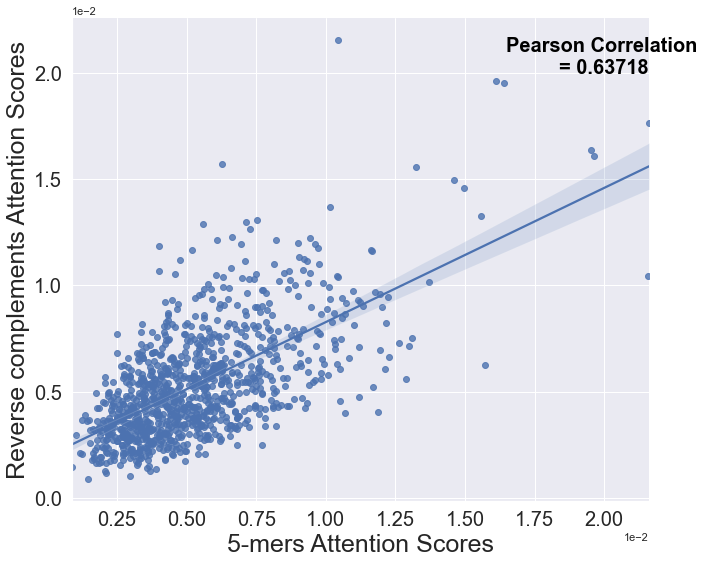

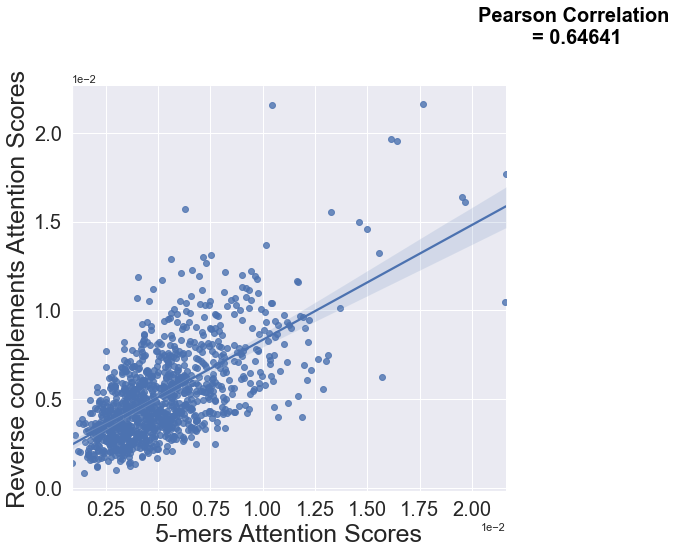

In [27]:
# reverseCompPlot(ordered_map0, fig_path + 'ordered_map_0.png', 0, 0)
reverseCompPlot(ordered_map_norm0, fig_path + 'ordered_map_0_norm', 0.02, 0.02, True)
reverseCompPlot(ordered_map_norm0, fig_path + 'ordered_map_0_norm', 0.025, 0.025, False)

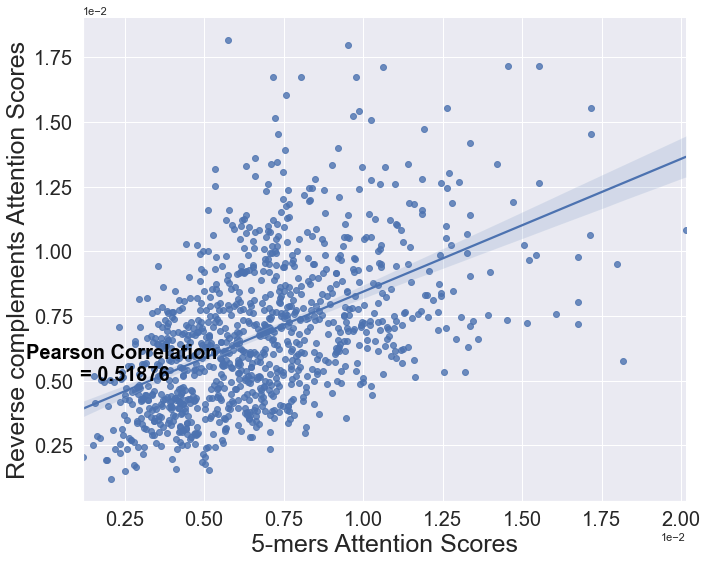

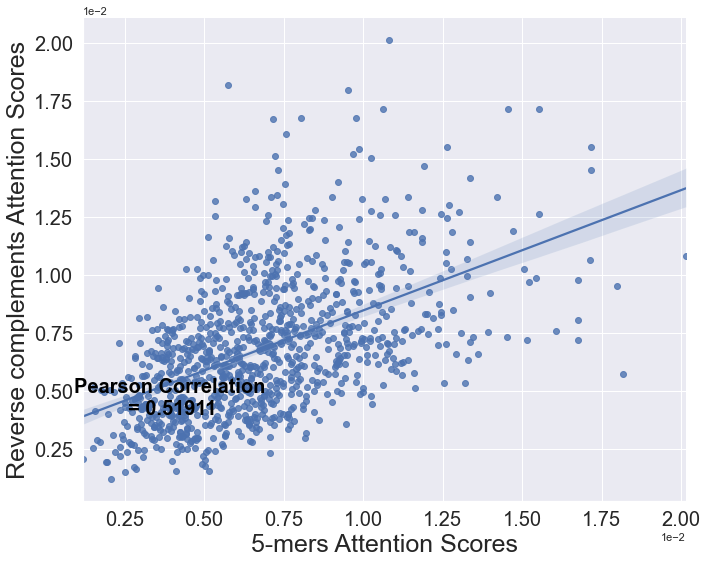

In [28]:
# reverseCompPlot(ordered_map1, fig_path + 'ordered_map_1.png', 0, 0)
reverseCompPlot(ordered_map_norm1, fig_path + 'ordered_map_1_norm',0.0025, 0.005, True)
reverseCompPlot(ordered_map_norm1, fig_path + 'ordered_map_1_norm',0.004, 0.004, False)

## 1.2 Add reverse complement scores to 5mer scores

In [16]:
def addReversCompScores(attention_outputs, d):
    # if you are using batches the outputs will be in batches
    # get exact attentions of chars
    from IPython.display import display
    mapped_add = {}
    seqCounts = 0
#     testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
#     d = testmat['Test_data']
    for seq in range(len(attention_outputs)):
        seqCounts+=1
    # for seq in range(1,5):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        for i in range(len(tokens)):
            token = tokens[i]
#             five_mer_attention_output = sum(attention_outputs[seq][i])
            five_mer_attention_output = attention_outputs[seq][i]
            if token in mapped_add.keys():  # if a 5mer is found
                mapped_add[token] = mapped_add[token] + five_mer_attention_output #increase value
                mapped_add[reverse_complement(token)] = mapped_add[token] #set the reverse compliement value to the same

            # if a 5mer's reverse complement is found
            elif reverse_complement(token) in mapped_add.keys():
                mapped_add[reverse_complement(token)] = mapped_add[reverse_complement(token)] + five_mer_attention_output
                mapped_add[token] = mapped_add[reverse_complement(token)] #set the original 5mer value to the same

            #if 5mer not seen yet
            else: 
                mapped_add[token] = five_mer_attention_output
                mapped_add[reverse_complement(token)] = mapped_add[token]
    #     char_df = plot_attention_from_seq(tokens, mapped[token])
    #     display(char_df)

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections
    ordered_map_add = collections.OrderedDict(sorted(mapped_add.items()))
    # char_df = plot_attention_from_map(mapped_add)
    # display(char_df)
    # char_df = plot_attention_from_map(ordered_map_add)
    # display(char_df)
    return ordered_map_add, seqCounts

In [ ]:
def addReversCompScoresKmer(attention_outputs, d):
    # if you are using batches the outputs will be in batches
    # get exact attentions of chars
    from IPython.display import display
    mapped_add = {}
    seqCounts = 0
#     testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
#     d = testmat['Test_data']
    for seq in range(len(attention_outputs)):
        seqCounts+=1
    # for seq in range(1,5):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        for i in range(len(tokens)):
            token = tokens[i]
#             five_mer_attention_output = sum(attention_outputs[seq][i])
            five_mer_attention_output = attention_outputs[seq][i]
            if token in mapped_add.keys():  # if a 5mer is found
                mapped_add[token] = mapped_add[token] + five_mer_attention_output #increase value
                mapped_add[reverse_complement(token)] = mapped_add[token] #set the reverse compliement value to the same

            # if a 5mer's reverse complement is found
            elif reverse_complement(token) in mapped_add.keys():
                mapped_add[reverse_complement(token)] = mapped_add[reverse_complement(token)] + five_mer_attention_output
                mapped_add[token] = mapped_add[reverse_complement(token)] #set the original 5mer value to the same

            #if 5mer not seen yet
            else: 
                mapped_add[token] = five_mer_attention_output
                mapped_add[reverse_complement(token)] = mapped_add[token]

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections
    ordered_map_add = collections.OrderedDict(sorted(mapped_add.items()))
    return ordered_map_add, seqCounts

In [17]:
import scipy
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
    
d=testmat['Test_data'] # need to redefine d
labels = testmat['Test_labels']
new_labels = labels[0]

# get the index of data that is 0 or 1 
ones = np.flatnonzero(new_labels == np.max(new_labels))
zeros = np.flatnonzero(new_labels == np.min(new_labels))
d0 = [d[i] for i in zeros]
d1 = [d[i] for i in ones]

ordered_map_add0, seqCounts0 = addReversCompScores(attention_outputs0, d0)
print("done1")
ordered_map_add1, seqCounts1 = addReversCompScores(attention_outputs1, d1)
print("done2")
ordered_map_add, seqCounts = addReversCompScores(attention_outputs, d)
print("done")

done1
done2
done


In [30]:
# print(ordered_kmerCounts.keys())
#################################### Kmer ####################################
def normKmerCount_addReverse(ordered_map, kmerCounts):
    ordered_map_add_norm = {}
    for k, _ in ordered_map.items():
        r = reverse_complement(k)
        v = ordered_map[k] / (kmerCounts[k] + kmerCounts[r])
        ordered_map_add_norm[k] = v
    return ordered_map_add_norm

print(len(ordered_map_add.keys()))
print(ordered_map_add['AAAAA'])
print(ordered_map_add['TTTTT'])
ordered_map_add_norm = normSeqCount_addReverse(ordered_map_add, kmerCounts)
ordered_map_add_norm0 = normSeqCount_addReverse(ordered_map_add0, kmerCounts0)
ordered_map_add_norm1 = normSeqCount_addReverse(ordered_map_add1, kmerCounts1)

In [18]:
# print(ordered_kmerCounts.keys())
#################################### Seq ####################################
def normSeqCount_addReverse(ordered_map, seqCounts):
    ordered_map_add_norm = {}
    for k, _ in ordered_map.items():
        r = reverse_complement(k)
        v = ordered_map[k]/ seqCounts
        ordered_map_add_norm[k] = v
    return ordered_map_add_norm

print(len(ordered_map_add.keys()))
print(ordered_map_add['AAAAA'])
print(ordered_map_add['TTTTT'])
ordered_map_add_norm = normSeqCount_addReverse(ordered_map_add, seqCounts)
ordered_map_add_norm0 = normSeqCount_addReverse(ordered_map_add0, seqCounts0)
ordered_map_add_norm1 = normSeqCount_addReverse(ordered_map_add1, seqCounts1)

1024
7244.6436
7244.6436


In [19]:
ordered_map_add1['ATATA']

277.21884

In [20]:
ordered_map_add_norm0['ATATA']

0.02531374099466143

In [21]:
ordered_map['CGCGC']

9.85204

In [36]:
ordered_map['ATATA']

1190.4534

In [37]:
ordered_map['AAAAA']

3653.1323

# 3. Shape vs Attention Score Corr Bar plots

In [22]:
#################### Add person correlation annotation All Normalized ###################
def plotAttention(whichAttention, shape_order, title):
    from scipy import stats
    AllDNAshape = ['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
    
    all_shape_df = {}
    for shape in AllDNAshape:
        cor = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        pval = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        r2 = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]**2
        all_shape_df[shape] = [cor]

    #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")

    df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson'])
    df["Shapes"] =all_shape_df.keys()
    
#     if (whichAttention == 'attention_score' or whichAttention == 'attention_score_norm'):
    if (whichAttention == 'attention_score'):
        df_sorted = df.sort_values(by=['Pearson'])
        shape_order = df_sorted['Shapes']
    else:
        for s in range(len(shape_order)):
            df.loc[shape_order[s], 'order'] = s
        df_sorted = df.sort_values(by=['order'])
#     p= sns.color_palette("Greens_d", len(df_sorted))
    p= sns.color_palette("mako", len(df_sorted))
    rank = df_sorted["Pearson"].argsort().argsort()
    
    #rocket
    ax = sns.catplot(y="Shapes",x="Pearson",data=df_sorted, kind="bar", edgecolor=".6", height=10,palette=np.array(p[::-1])[rank])

    ax.set_axis_labels("Pearson Correlation", "Shapes", fontsize=18)
    ax.set_yticklabels(fontsize=12)
    ax.set_xticklabels(fontsize=12)
    ax.set_titles(title,fontsize=12)

    plt.tight_layout()
    plt.title(whichAttention)
    if whichAttention == 'attention_score': whichAttention=whichAttention+"_all"
    if whichAttention == 'attention_score_norm': whichAttention=whichAttention+"norm_all"
#     plt.savefig( fig_path + whichAttention + '.png', dpi=200, bbox_inches='tight')
    return shape_order, df_sorted


In [31]:
tb['AAAAA']

[0.1585,
 -0.0098,
 -0.0836,
 8.002,
 -14.9156,
 -2.0769,
 3.8846,
 -10.6188,
 0.2544,
 0.1209,
 0.3444,
 8.1741,
 7.1416,
 4.7619,
 1.3501,
 -0.0859,
 -0.0859,
 -1.0338,
 -1.0338,
 3.2774,
 3.2774,
 -0.9298,
 -0.9298,
 -4.685,
 -4.685,
 37.6927,
 37.6927,
 0.5549,
 0.5549,
 0.446,
 0.446,
 0.2934,
 0.2934,
 3.3414,
 3.3414,
 5.8623,
 5.8623,
 3.9465,
 3.9465]

In [23]:
shapes = ['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']

for i in range(len(tb['TTTTT'])):
    if  tb['TTTTT'][i] != tb['AAAAA'][i]:
        print(shapes[i])
#         print("AAAAA")
#         print(tb['AAAAA'][i])
#         print("TTTTT")
#         print(tb['TTTTT'][i])

Shear
Buckle
Shift_-1
Shift_1
Tilt_-1
Tilt_1


        Shear  Stretch  Stagger   Buckle     ProT  Opening     MGW      EP  \
CAAAC  0.1444  -0.0294  -0.0829   7.9578 -13.0735  -2.0287  4.9287 -8.2657   
ACCTT  0.2756  -0.0203   0.1321  -3.8319  -1.5547   0.5418  3.8571 -4.1795   
CATTG -0.1449  -0.0268  -0.0412  -3.2138 -10.1757  -1.4528  4.7283 -7.9404   
GTACG  0.1141  -0.0303   0.0591   2.7091  -8.8274  -0.8610  5.9860 -6.7229   
CAAGG  0.1364  -0.0182   0.0466   7.4618  -9.1585  -1.0383  4.7803 -7.7166   
...       ...      ...      ...      ...      ...      ...     ...     ...   
GCGTT -0.2568  -0.0200  -0.0890  -7.5224  -9.8384   0.8647  4.6725 -5.0260   
AAACC  0.1592  -0.0007   0.0846  11.7371 -12.3719  -0.6203  4.1336 -8.9382   
ATGAC -0.2856  -0.0416   0.0142  -0.8583  -6.3995   0.2646  5.4694 -5.1848   
CCGCG -0.2806  -0.0301   0.0626   1.8517  -3.9537   0.4206  5.5014 -4.1247   
ACCGG  0.2483  -0.0395  -0.0008   2.1275  -4.8130   0.3453  5.1150 -4.0000   

       Shear-FL  Stretch-FL  ...  Slide-FL_-1  Slide-FL_1  Rise

(EP                      EP
 ProT                  ProT
 Opening            Opening
 MGW                    MGW
 Stagger            Stagger
 Roll_1              Roll_1
 Roll_-1            Roll_-1
 Rise_-1            Rise_-1
 Rise_1              Rise_1
 Stretch-FL      Stretch-FL
 Shift_1            Shift_1
 Tilt_1              Tilt_1
 Tilt-FL_1        Tilt-FL_1
 Tilt-FL_-1      Tilt-FL_-1
 Buckle              Buckle
 Shear                Shear
 Tilt_-1            Tilt_-1
 Shift_-1          Shift_-1
 Slide-FL_1      Slide-FL_1
 Slide-FL_-1    Slide-FL_-1
 HelT-FL_-1      HelT-FL_-1
 HelT-FL_1        HelT-FL_1
 Rise-FL_1        Rise-FL_1
 Rise-FL_-1      Rise-FL_-1
 Shear-FL          Shear-FL
 Roll-FL_-1      Roll-FL_-1
 Roll-FL_1        Roll-FL_1
 Buckle-FL        Buckle-FL
 HelT_-1            HelT_-1
 HelT_1              HelT_1
 Stagger-FL      Stagger-FL
 Slide_1            Slide_1
 Slide_-1          Slide_-1
 Stretch            Stretch
 Shift-FL_-1    Shift-FL_-1
 Shift-FL_1      Shi

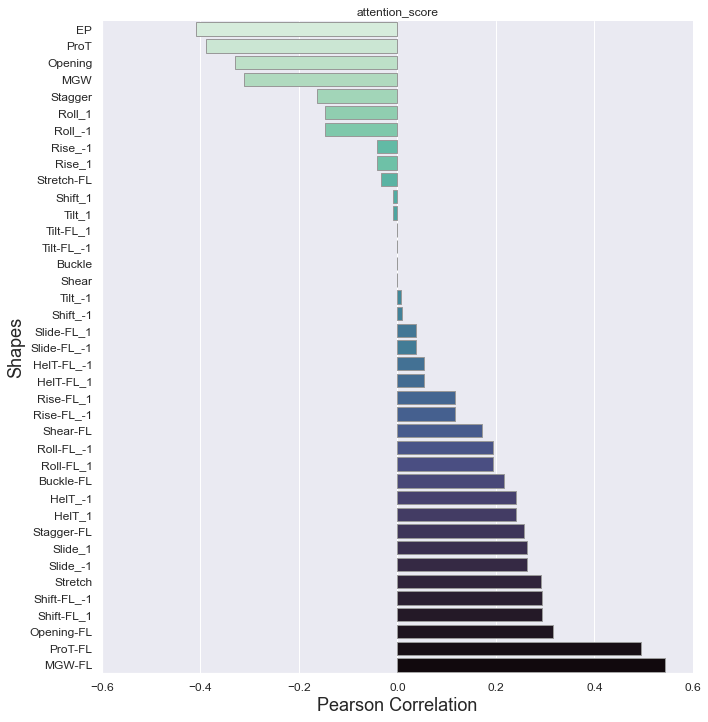

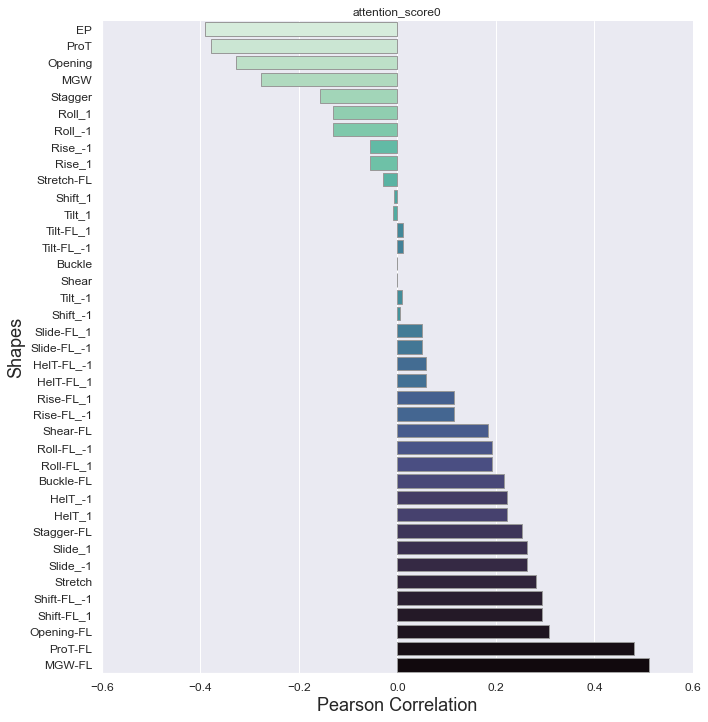

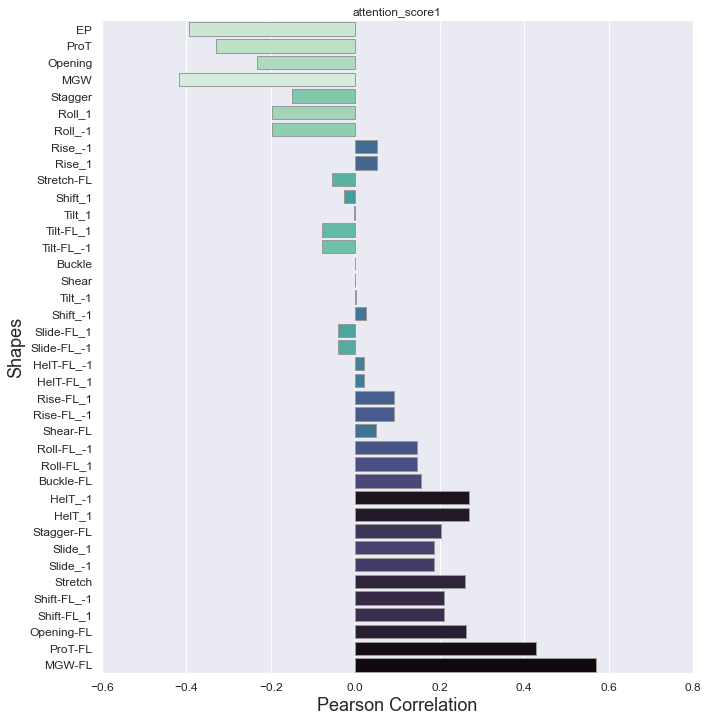

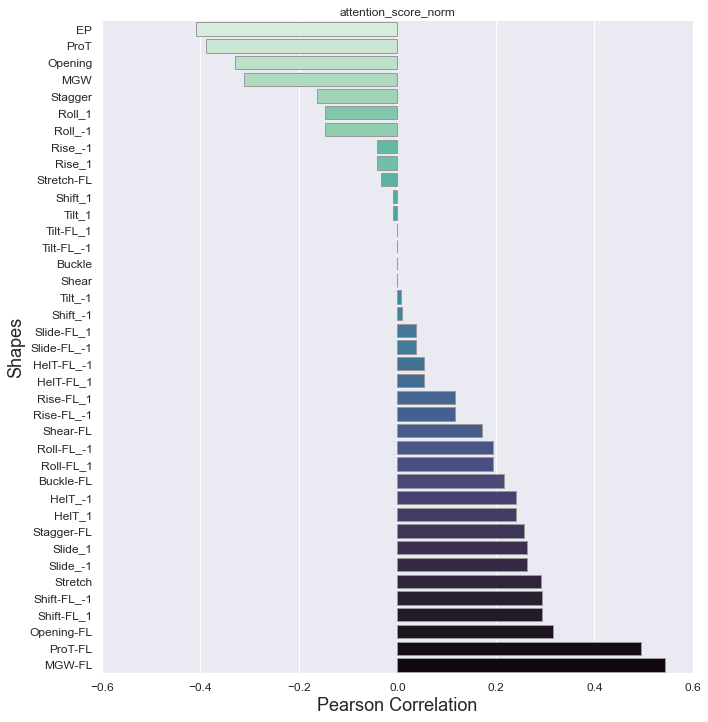

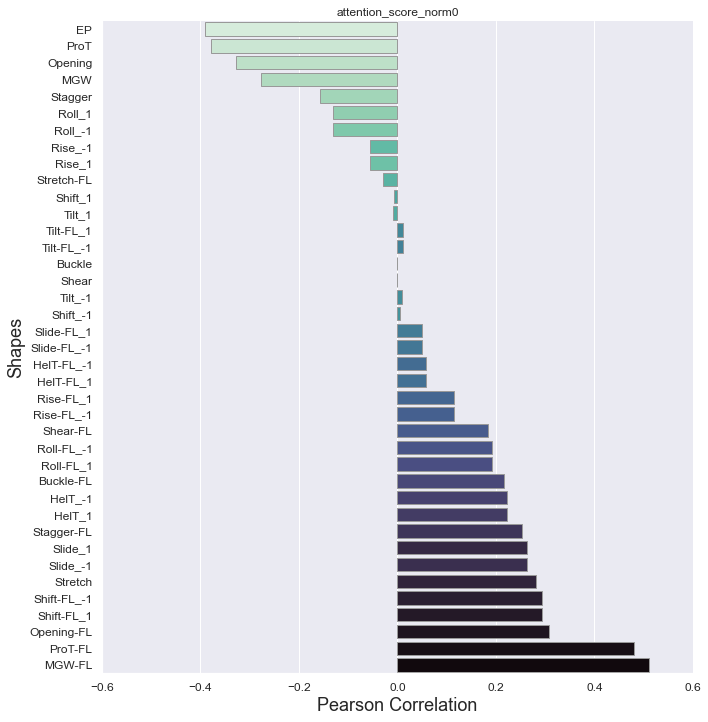

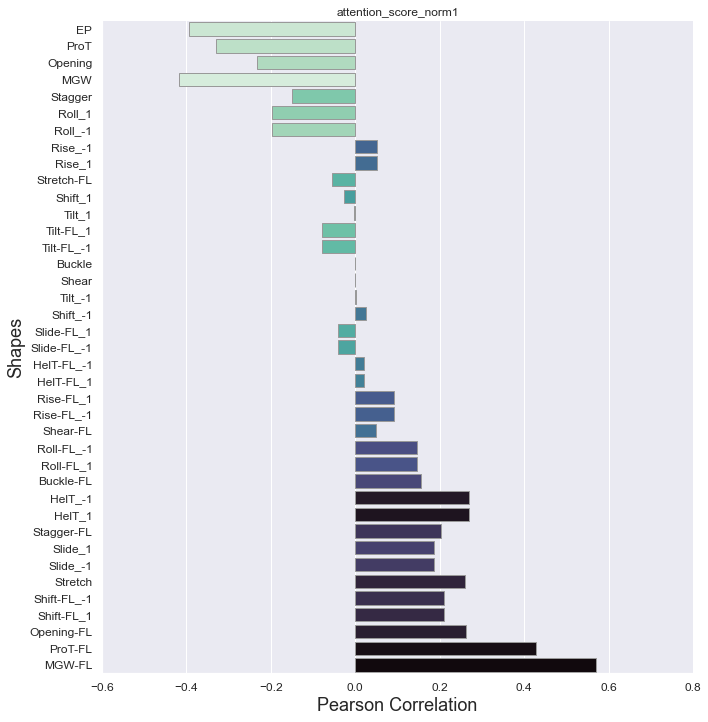

In [47]:
################################### Correlation plots for DNA shape SEQ COUNT ###################################
import seaborn as sns
import matplotlib.pyplot

# use added reverse complement score way
attention_score0 = []
attention_score1 = []
attention_score = []
attention_score_norm0 = []
attention_score_norm1 = []
attention_score_norm = []

for k in tb.items(): # set values to the 5mer order as seen in tb
    attention_score.append(ordered_map_add[k[0]]) 
    attention_score0.append(ordered_map_add0[k[0]])
    attention_score1.append(ordered_map_add1[k[0]])
    
    attention_score_norm.append(ordered_map_add_norm[k[0]]) 
    attention_score_norm0.append(ordered_map_add_norm0[k[0]])
    attention_score_norm1.append(ordered_map_add_norm1[k[0]])

# shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD'])

shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1'])
print(shape_df)
shape_df['attention_score'] = attention_score
shape_df['attention_score0'] = attention_score0
shape_df['attention_score1'] = attention_score1

shape_df['attention_score_norm'] = attention_score_norm
shape_df['attention_score_norm0'] = attention_score_norm0
shape_df['attention_score_norm1'] = attention_score_norm1

shape_ordered,df_sorted = plotAttention('attention_score', [],'Attention Score' )
_,df_sorted0=plotAttention('attention_score0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences')
_,df_sorted1=plotAttention('attention_score1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences' )

# shape_ordered = plotAttention('attention_score_norm', [],'Attention Score Normalized' )
plotAttention('attention_score_norm', shape_ordered,'Attention Score Normalized' )
plotAttention('attention_score_norm0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences Normalized')
plotAttention('attention_score_norm1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences Normalized' )



        Shear  Stretch  Stagger   Buckle     ProT  Opening     MGW      EP  \
CAAAC  0.1444  -0.0294  -0.0829   7.9578 -13.0735  -2.0287  4.9287 -8.2657   
ACCTT  0.2756  -0.0203   0.1321  -3.8319  -1.5547   0.5418  3.8571 -4.1795   
CATTG -0.1449  -0.0268  -0.0412  -3.2138 -10.1757  -1.4528  4.7283 -7.9404   
GTACG  0.1141  -0.0303   0.0591   2.7091  -8.8274  -0.8610  5.9860 -6.7229   
CAAGG  0.1364  -0.0182   0.0466   7.4618  -9.1585  -1.0383  4.7803 -7.7166   
...       ...      ...      ...      ...      ...      ...     ...     ...   
GCGTT -0.2568  -0.0200  -0.0890  -7.5224  -9.8384   0.8647  4.6725 -5.0260   
AAACC  0.1592  -0.0007   0.0846  11.7371 -12.3719  -0.6203  4.1336 -8.9382   
ATGAC -0.2856  -0.0416   0.0142  -0.8583  -6.3995   0.2646  5.4694 -5.1848   
CCGCG -0.2806  -0.0301   0.0626   1.8517  -3.9537   0.4206  5.5014 -4.1247   
ACCGG  0.2483  -0.0395  -0.0008   2.1275  -4.8130   0.3453  5.1150 -4.0000   

       Shear-FL  Stretch-FL  ...  Slide-FL_-1  Slide-FL_1  Rise

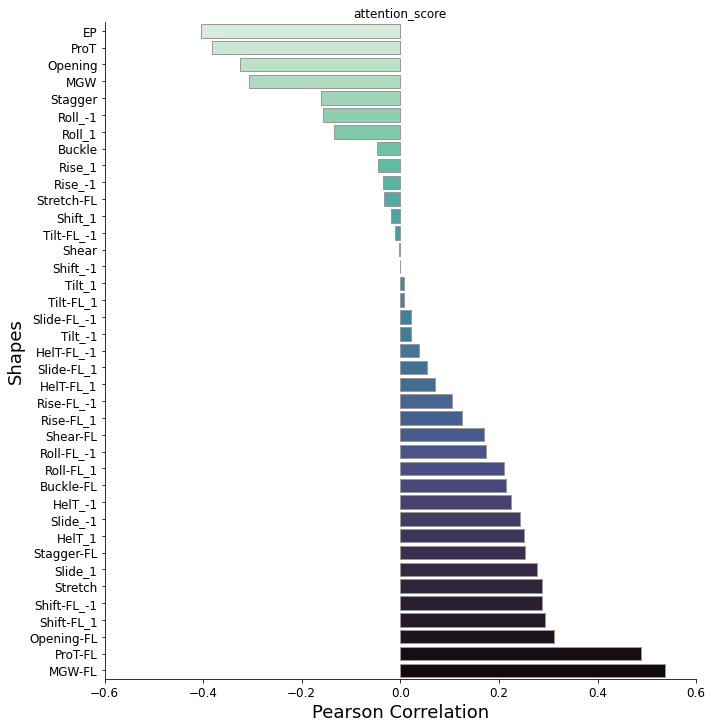

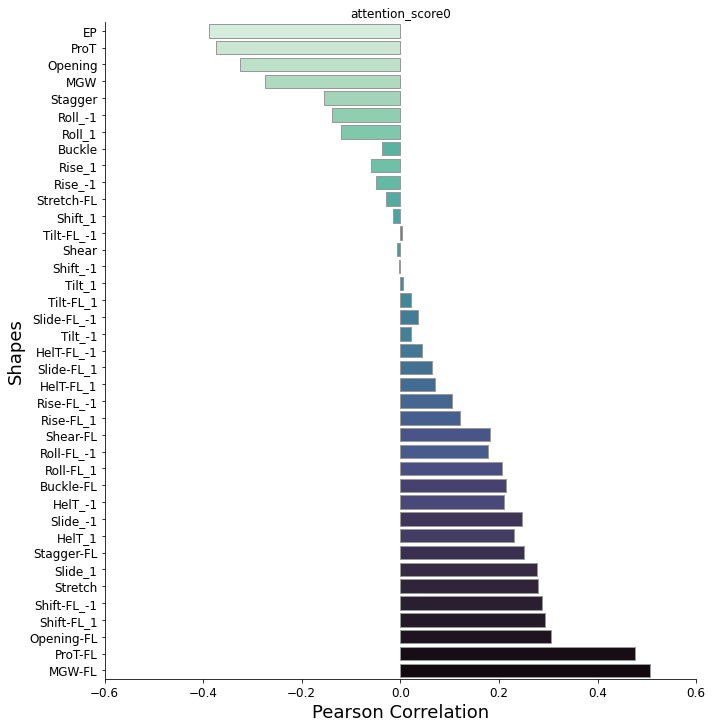

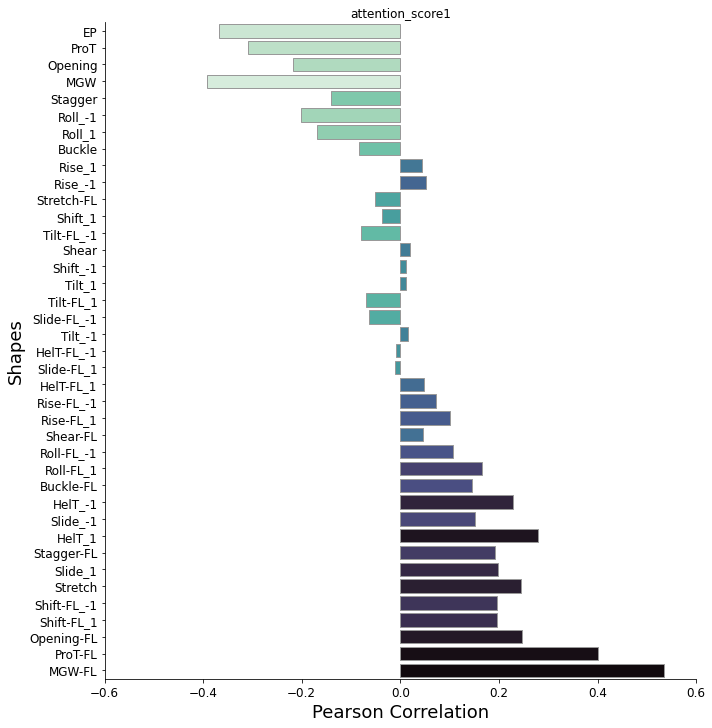

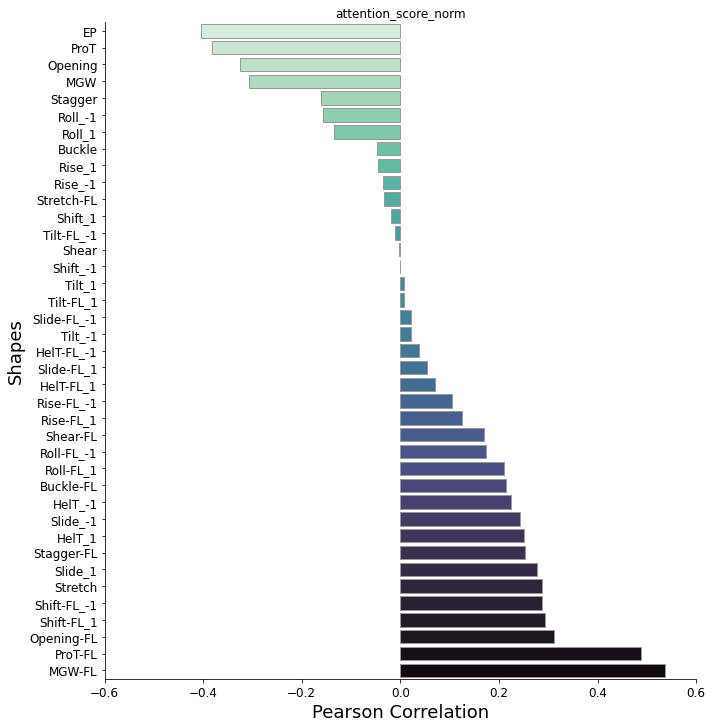

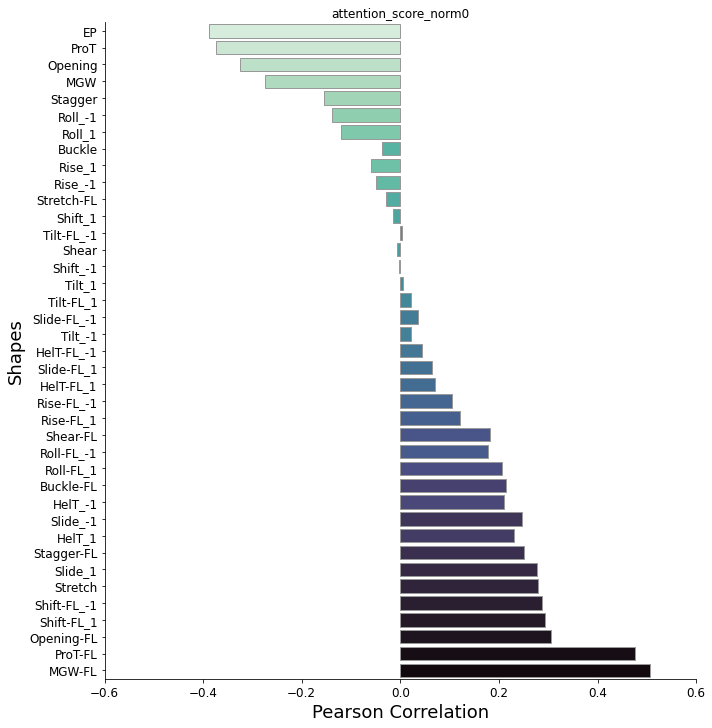

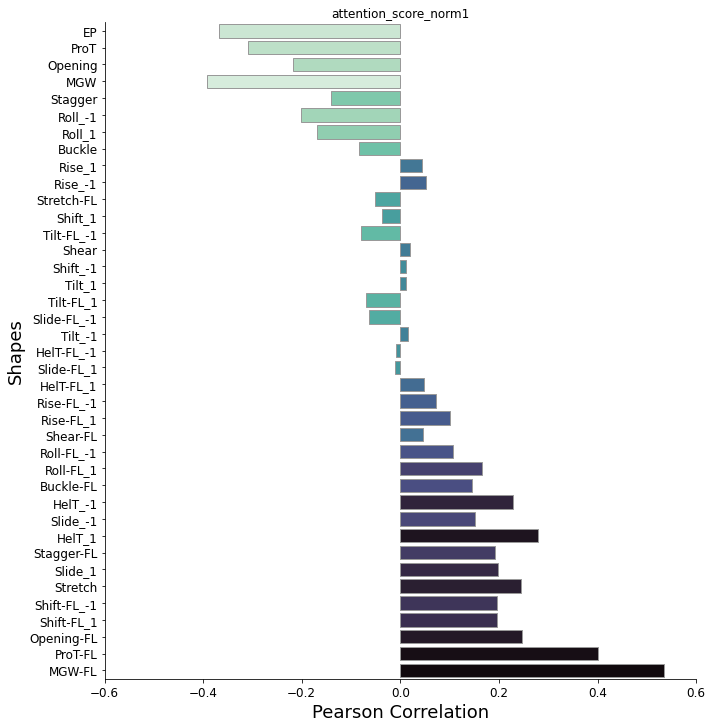

In [25]:
################################### Correlation plots for DNA shape kmer norm ###################################
import seaborn as sns
import matplotlib.pyplot

# use added reverse complement score way
attention_score0 = []
attention_score1 = []
attention_score = []
attention_score_norm0 = []
attention_score_norm1 = []
attention_score_norm = []

for k in tb.items(): # set values to the 5mer order as seen in tb
    attention_score.append(ordered_map[k[0]]) 
    attention_score0.append(ordered_map0[k[0]])
    attention_score1.append(ordered_map1[k[0]])
    
    attention_score_norm.append(ordered_map_norm[k[0]]) 
    attention_score_norm0.append(ordered_map_norm0[k[0]])
    attention_score_norm1.append(ordered_map_norm1[k[0]])

# shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD'])

shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1'])
print(shape_df)
shape_df['attention_score'] = attention_score
shape_df['attention_score0'] = attention_score0
shape_df['attention_score1'] = attention_score1

shape_df['attention_score_norm'] = attention_score_norm
shape_df['attention_score_norm0'] = attention_score_norm0
shape_df['attention_score_norm1'] = attention_score_norm1

shape_ordered,df_sorted = plotAttention('attention_score', [],'Attention Score' )
_,df_sorted0=plotAttention('attention_score0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences')
_,df_sorted1=plotAttention('attention_score1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences' )

# shape_ordered = plotAttention('attention_score_norm', [],'Attention Score Normalized' )
_,df_sorted_norm=plotAttention('attention_score_norm', shape_ordered,'Attention Score Normalized' )
_,df_sorted_norm0=plotAttention('attention_score_norm0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences Normalized')
_,df_sorted_norm1=plotAttention('attention_score_norm1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences Normalized' )



In [50]:
# df_sorted_norm.to_csv('~/Downloads/data/df_sorted_all_kmerNorm.csv')  
# df_sorted_norm0.to_csv('~/Downloads/data/df_sorted0_kmerNorm.csv')  
# df_sorted_norm1.to_csv('~/Downloads/data/df_sorted1_kmerNorm.csv')  

<AxesSubplot:>

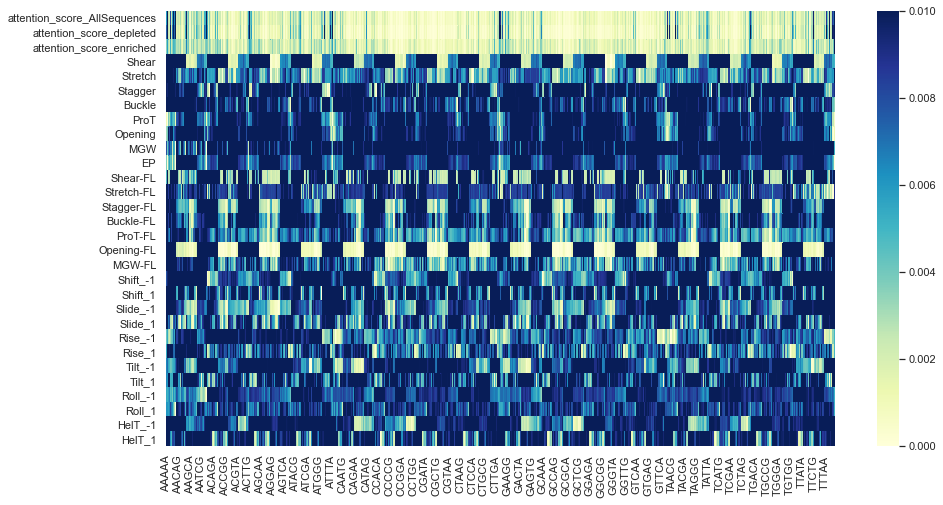

In [50]:
# new_df = shape_df.drop(columns=good_model, axis=1)toplot = shape_df.pivot("kmer", "Shear")
# attention_score	
shape_df['kmer']=tb.keys()
shape_df.sort_values(by=['kmer'], inplace=True)
shape='ProT'
AllDNAshape =['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1']

data = {'attention_score_AllSequences':shape_df['attention_score_norm'],
           'attention_score_depleted':shape_df['attention_score_norm0'],
           'attention_score_enriched':shape_df['attention_score_norm1']}
new_df=pd.DataFrame(data)# ax = sns.heatmap(toplot)


for shape in AllDNAshape:
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
    for i in shape_arr:
        new_shape_arr.append(i*0.02)    
    new_df[shape]=new_shape_arr

    # new_df['attention_score']
    
df_all_transposed = new_df.transpose()
sns.set(rc = {'figure.figsize':(15,8)})
# print(new_df)
sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.01)




In [87]:
print(shape_df['attention_score_norm0'])
min_max_norm(shape_df['attention_score_norm0'])

AAAAA    0.072148
AAAAC    0.007389
AAAAG    0.013419
AAAAT    0.030866
AAACA    0.006333
           ...   
TTTGT    0.005852
TTTTA    0.013000
TTTTC    0.012079
TTTTG    0.009405
TTTTT    0.072148
Name: attention_score_norm0, Length: 1024, dtype: float64


[1.0,
 0.10160789033406585,
 0.1852577848806967,
 0.4272948923559388,
 0.08696039590760385,
 0.03452699349737331,
 0.02578806460074893,
 0.07224766043809284,
 0.1380638680420288,
 0.02810540158995692,
 0.04991353831162863,
 0.0934547699999529,
 0.3026568585204106,
 0.08943428783406099,
 0.10095079441468509,
 0.27560502668045067,
 0.07194004931288472,
 0.01889501732246744,
 0.021725059543812444,
 0.05536683281462547,
 0.02570745940527146,
 0.016839591768988554,
 0.006821974932906194,
 0.03464001127847774,
 0.014491792170792647,
 0.005658644053399839,
 0.006299522705572533,
 0.019526040390697,
 0.0405718933536249,
 0.031027691106642122,
 0.015325794175793458,
 0.07129556355048962,
 0.15709681372172465,
 0.019162261158768717,
 0.04117463020859401,
 0.059402161603600914,
 0.02493739191276349,
 0.009348532401409577,
 0.005320261303356076,
 0.02350467892280961,
 0.040910394511610305,
 0.011952621079705303,
 0.01997600212095424,
 0.035315292347296794,
 0.0489872393377121,
 0.02324977261642835

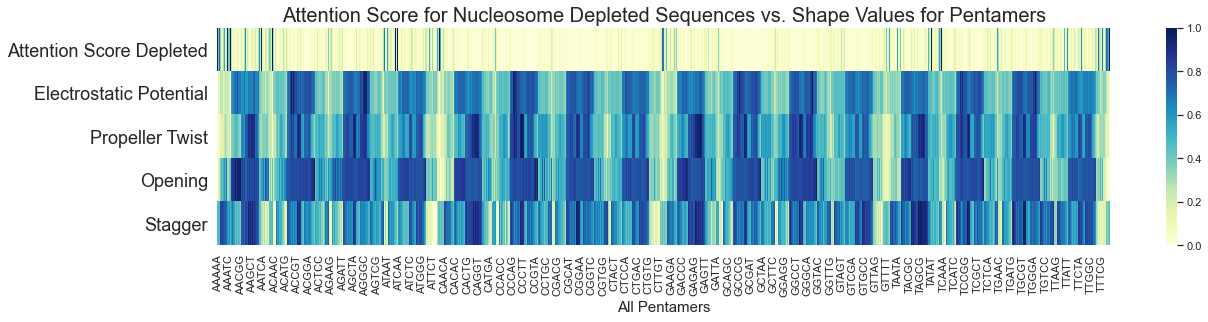

In [190]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['EP','ProT','Opening', 'Stagger']
# AllDNAshape_FL=['ProT-FL','MGW-FL']
AllDNAshape_names=AllDNAshape_FL
AllDNAshape_names=['Electrostatic Potential','Propeller Twist','Opening', 'Stagger']
normed=min_max_norm(shape_df['attention_score_norm0'])
new_normed=[]
for i in normed:
    new_normed.append(i*4)
shape_df['attention_score_norm0_scaleAdjusted']=new_normed

data = {'Attention Score Depleted':shape_df['attention_score_norm0_scaleAdjusted']}
new_df=pd.DataFrame(data)
for j in range(len(AllDNAshape_FL)):
    shape=AllDNAshape_FL[j]
    shape_arr = min_max_norm(shape_df[shape])
#     new_shape_arr=[]
    new_shape_arr=shape_arr
#     for i in shape_arr:
#         new_shape_arr.append(i*0.02)   

    name=AllDNAshape_names[j]
    new_df[name]=new_shape_arr
# print(shape_arr)
df_all_transposed = new_df.transpose()
# print(new_df)
# sns.set(rc = {'figure.figsize':(15,8)})

ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_title('Attention Score for Nucleosome Depleted Sequences vs. Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
sns.set(rc = {'figure.figsize':(20,4)})

ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_depleted_NegCorr.png', dpi=200, bbox_inches='tight')
# plt.show()
# df_all_transposed



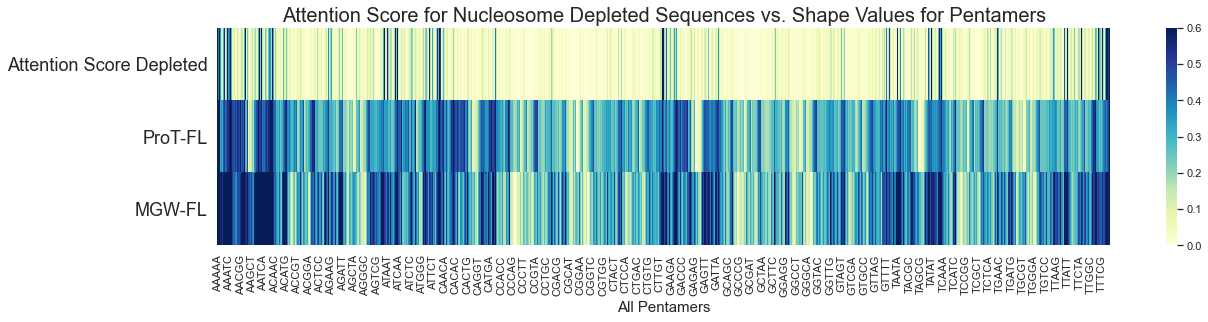

In [189]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['ProT-FL', 'MGW-FL']
# AllDNAshape_FL=['ProT-FL','MGW-FL']
AllDNAshape_names=AllDNAshape_FL
# AllDNAshape_names=['Electrostatic Potential','Propeller Twist','Opening', 'Stagger']
normed=min_max_norm(shape_df['attention_score_norm0'])
new_normed=[]
for i in normed:
    new_normed.append(i*4)
shape_df['attention_score_norm0_scaleAdjusted']=new_normed

data = {'Attention Score Depleted':shape_df['attention_score_norm0_scaleAdjusted']}
new_df=pd.DataFrame(data)
for j in range(len(AllDNAshape_FL)):
    shape=AllDNAshape_FL[j]
    shape_arr = min_max_norm(shape_df[shape])
#     new_shape_arr=[]
    new_shape_arr=shape_arr
#     for i in shape_arr:
#         new_shape_arr.append(i*0.02)   

    name=AllDNAshape_names[j]
    new_df[name]=new_shape_arr
# print(shape_arr)
df_all_transposed = new_df.transpose()
# print(new_df)
# sns.set(rc = {'figure.figsize':(15,8)})

ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.6)
ax.set_title('Attention Score for Nucleosome Depleted Sequences vs. Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
sns.set(rc = {'figure.figsize':(20,4)})

ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_depleted_NegCorr.png', dpi=200, bbox_inches='tight')
# plt.show()
# df_all_transposed



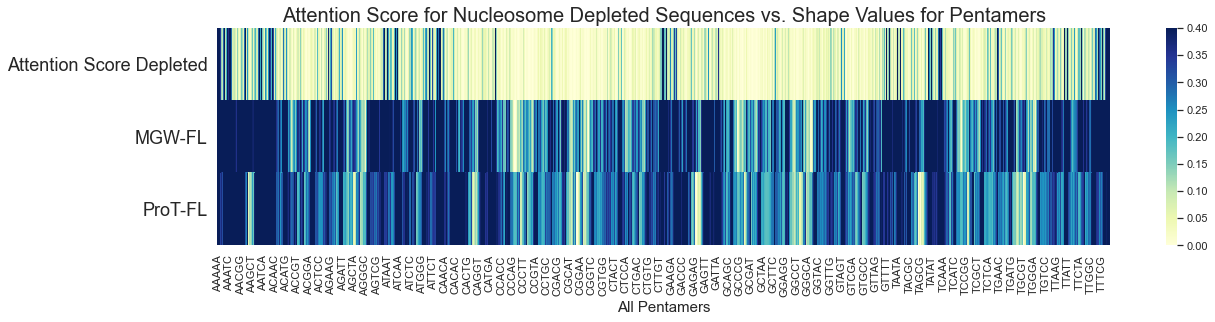

In [165]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['MGW-FL','ProT-FL']
# AllDNAshape_FL=['ProT-FL','MGW-FL']
AllDNAshape_names=AllDNAshape_FL
# AllDNAshape_names=['Opening','Propeller Twist', 'Electrostatic Potential','Stagger']
# normed=min_max_norm(shape_df['attention_score_norm0'])
# new_normed=[]
# for i in normed:
#     new_normed.append(i*4)
# normed=min_max_norm(shape_df['attention_score_norm0'])
# new_normed=[]
# for i in normed:
#     new_normed.append(i*4)
# shape_df['attention_score_norm0_scaleAdjusted']=new_normed

data = {'Attention Score Depleted':shape_df['attention_score_norm0_scaleAdjusted']}
new_df=pd.DataFrame(data)
for j in range(len(AllDNAshape_FL)):
    shape=AllDNAshape_FL[j]
    shape_arr = min_max_norm(shape_df[shape])
#     new_shape_arr=[]
    new_shape_arr=shape_arr
#     for i in shape_arr:
#         new_shape_arr.append(i*0.02)   

    name=AllDNAshape_names[j]
    new_df[name]=new_shape_arr
# print(shape_arr)
df_all_transposed = new_df.transpose()
# print(new_df)
# sns.set(rc = {'figure.figsize':(15,8)})

ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.4)
ax.set_title('Attention Score for Nucleosome Depleted Sequences vs. Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
sns.set(rc = {'figure.figsize':(20,4)})

ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_depleted_PosCorr.png', dpi=200, bbox_inches='tight')
# plt.show()
# df_all_transposed



Text(0.5, 1.0, 'Attention Score Depleted')

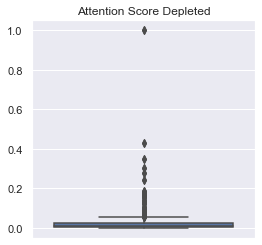

In [182]:
import seaborn as sns
sns.set(rc = {'figure.figsize':(4,4)})
ax=sns.boxplot(y=min_max_norm(shape_df['attention_score_norm0']))
ax.set_title('Attention Score Depleted')
# ax=sns.boxplot(x=shape_df['MGW-FL'])

Text(0.5, 1.0, 'ProT-FL')

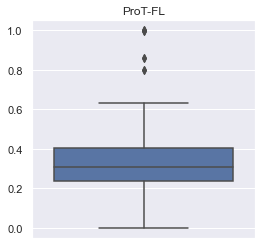

In [180]:
sns.set(rc = {'figure.figsize':(4,4)})
ax=sns.boxplot(y=min_max_norm(shape_df['ProT-FL']))
ax.set_title('ProT-FL')


Text(0.5, 1.0, 'MGW-FL')

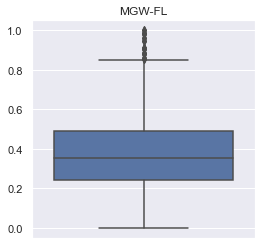

In [181]:
sns.set(rc = {'figure.figsize':(4,4)})

ax=sns.boxplot(y=min_max_norm(shape_df['MGW-FL']))
ax.set_title('MGW-FL')


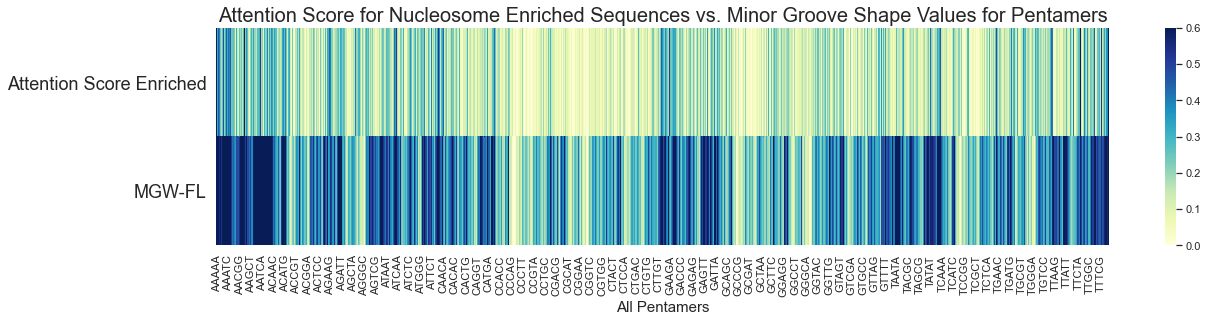

In [185]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['MGW-FL']
normed=min_max_norm(shape_df['attention_score_norm1'])
new_normed=[]
for i in normed:
    new_normed.append(i)
shape_df['attention_score_norm1_scaleAdjusted']=new_normed


data = {'Attention Score Enriched':shape_df['attention_score_norm1_scaleAdjusted']}
new_df=pd.DataFrame(data)# ax = sns.heatmap(toplot

for shape in AllDNAshape_FL:
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
#     for i in shape_arr:
#         new_shape_arr.append(i*0.001)    
#     new_df[shape]=new_shape_arr
    new_df[shape]=shape_arr    

    # new_df['attention_score']
    
df_all_transposed = new_df.transpose()
sns.set(rc = {'figure.figsize':(20,4)})
# print(new_df)
ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.6)
ax.set_title('Attention Score for Nucleosome Enriched Sequences vs. Minor Groove Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)

fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_enriched.png', dpi=200, bbox_inches='tight')

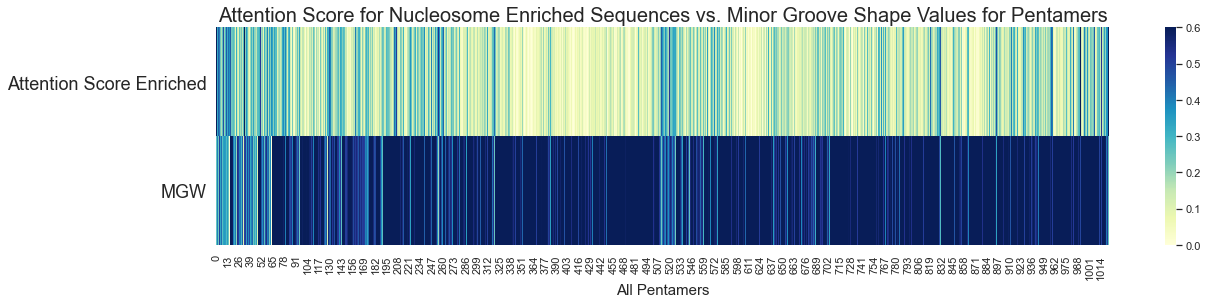

In [183]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['MGW']
data = {   'Attention Score Enriched':min_max_norm(shape_df['attention_score_norm1'])}
new_df=pd.DataFrame(data)# ax = sns.heatmap(toplot

for shape in AllDNAshape_FL:
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
#     for i in shape_arr:
#         new_shape_arr.append(i*0.001)    
#     new_df[shape]=new_shape_arr
    new_df[shape]=shape_arr    

    # new_df['attention_score']
    
df_all_transposed = new_df.transpose()
sns.set(rc = {'figure.figsize':(20,4)})
# print(new_df)
ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.6)
ax.set_title('Attention Score for Nucleosome Enriched Sequences vs. Minor Groove Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)

fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_enriched.png', dpi=200, bbox_inches='tight')

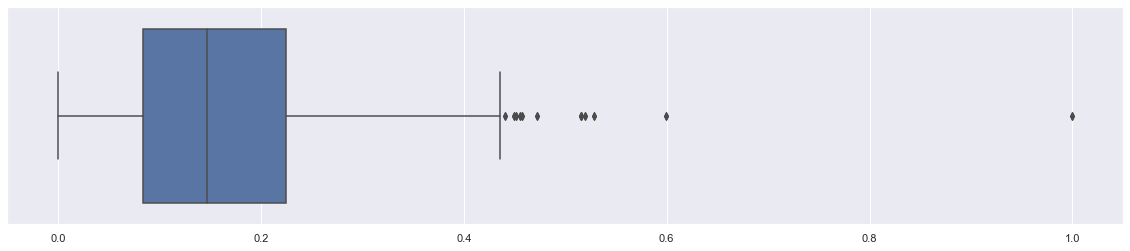

In [116]:
import seaborn as sns
ax=sns.boxplot(x=min_max_norm(shape_df['attention_score_norm1']))
# ax=sns.boxplot(x=shape_df['MGW-FL'])

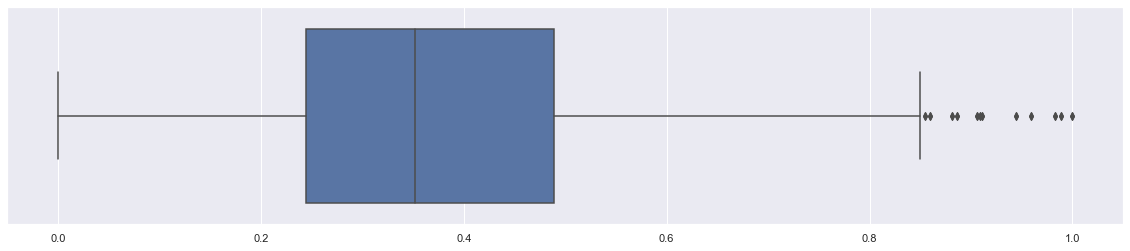

In [115]:
ax=sns.boxplot(x=min_max_norm(shape_df['MGW-FL']))


In [97]:
shape_df

,Shear,Stretch,Stagger,Buckle,ProT,Opening,MGW,EP,Shear-FL,Stretch-FL,...,Roll-FL_1,HelT-FL_-1,HelT-FL_1,attention_score,attention_score0,attention_score1,attention_score_norm,attention_score_norm0,attention_score_norm1,kmer
AAAAA,0.1585,-0.0098,-0.0836,8.0020,-14.9156,-2.0769,3.8846,-10.6188,0.2544,0.1209,...,5.8623,3.9465,3.9465,7244.643555,6610.316895,634.174072,0.048013,0.072148,0.010700,AAAAA
AAAAC,0.1494,-0.0117,-0.0663,8.8585,-14.4945,-1.7474,4.3160,-9.0660,0.2429,0.1243,...,5.4856,3.8645,3.7156,890.525391,676.979614,213.549698,0.005902,0.007389,0.003603,AAAAC
AAAAG,0.1582,-0.0054,-0.0874,8.0892,-14.4479,-1.5057,3.8397,-10.3464,0.2504,0.1230,...,6.0097,3.8673,3.7298,1521.519531,1229.436646,292.089630,0.010084,0.013419,0.004928,AAAAG
AAAAT,0.1675,-0.0027,-0.0752,8.7426,-15.3464,-1.6260,3.7040,-10.4979,0.2570,0.1295,...,5.8028,3.8369,3.9573,3169.052490,2827.945557,341.088287,0.021002,0.030866,0.005755,AAAAT
AAACA,0.1457,-0.0053,0.1243,12.2045,-13.1763,-1.1268,4.6698,-8.1077,0.2426,0.1233,...,4.7009,3.6955,3.4661,841.851624,580.241760,261.610870,0.005579,0.006333,0.004414,AAACA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGT,-0.0892,-0.0317,-0.2442,-2.2202,-11.9197,-1.6432,5.3309,-7.6962,0.2500,0.1085,...,5.6246,3.8280,4.0518,755.608398,536.127625,219.483490,0.005008,0.005852,0.003703,TTTGT
TTTTA,-0.1523,-0.0281,-0.1079,-6.9864,-13.4145,-2.1393,4.9203,-8.3192,0.2463,0.1070,...,4.8805,3.9224,3.8776,1330.559448,1191.046265,139.509537,0.008818,0.013000,0.002354,TTTTA
TTTTC,-0.1497,-0.0198,-0.1349,-5.9280,-12.6478,-2.0386,4.3607,-9.3758,0.2413,0.1079,...,5.3692,3.9378,3.8949,1345.430298,1106.681519,238.742828,0.008917,0.012079,0.004028,TTTTC
TTTTG,-0.1493,-0.0290,-0.1110,-7.0184,-13.4225,-2.2708,4.6594,-8.8477,0.2500,0.1065,...,5.1891,3.9373,3.8573,1108.598633,861.679871,246.927032,0.007347,0.009405,0.004166,TTTTG
